> **데이터셋 안내** — 이 노트북이 참조하는 HF 데이터셋은 공개 배포하지 않는다.
> AI Hub 원본에서 재생성하는 절차는 [docs/data/data-pipeline.md](../docs/data/data-pipeline.md)「가공 데이터셋은 배포하지 않는다 — 재현 경로」에 있다.

- 02_01 에서 토큰화 데이터셋 생성시 훈련을 고려 max_lenth=512로 잘라서 데이터셋의 원래 길이 확인 불가. KoBERT로 다시 토큰화해서 truncation 문서에 대한 데이터 탐색 진행

In [ ]:
import os
from dotenv import load_dotenv
from pathlib import Path
import numpy as np
import random
from numpy.typing import NDArray

load_dotenv()
ROOT = Path(os.environ["DATA_ROOT"])
HF_HOME = ROOT / ".hf_cache"
os.environ["HF_HOME"] = str(HF_HOME)

import torch
from transformers import AutoTokenizer
from datasets import load_dataset

In [2]:
# Config
config = {
    'num_labels': 188,
    'seed': 42,
    'model_name': 'monologg/kobert',
}

In [3]:
random.seed(config['seed'])
np.random.seed(config['seed'])
torch.manual_seed(config['seed'])
torch.cuda.manual_seed_all(config['seed'])

## 데이터셋

In [4]:
dataset = load_dataset("ingyoun/patent-clean-text")
dataset

DatasetDict({
    train: Dataset({
        features: ['document_id', 'invention_title', 'abstract', 'claims', 'ipc_main', 'mno', 'label_ids', 'lno'],
        num_rows: 201895
    })
    test: Dataset({
        features: ['document_id', 'invention_title', 'abstract', 'claims', 'ipc_main', 'mno', 'label_ids', 'lno'],
        num_rows: 11271
    })
    val: Dataset({
        features: ['document_id', 'invention_title', 'abstract', 'claims', 'ipc_main', 'mno', 'label_ids', 'lno'],
        num_rows: 11162
    })
})

In [5]:
REV = "38279184ba645e8c94d709fbe92eb5bcb47312c1"
tokenizer = AutoTokenizer.from_pretrained(config["model_name"], trust_remote_code=True, revision=REV)

In [6]:
print(f"Vocab Size: {tokenizer.vocab_size}")
print(f"Max Length: {tokenizer.model_max_length}")
print(f"Max Length: {tokenizer.all_special_tokens}")

Vocab Size: 8002
Max Length: 512
Max Length: ['[UNK]', '[SEP]', '[PAD]', '[CLS]', '[MASK]']


## 토큰화

In [7]:
def build_inputs(ex):
    inputs = dict()
    fields = ["invention_title", "ipc_main", "abstract", "claims"]
    text = " ".join(str(ex[field]) for field in fields if ex[field])   # 빈 필드 skip, 개행/들여쓰기 없음
    return {
        "document_id": ex["document_id"],
        "input" : text,
        "label_ids": ex["label_ids"]
    }

def to_features(ex):
    out = tokenizer(ex["input"])
    batch_size = len(ex["input"])
    y = np.zeros((batch_size, config["num_labels"]), dtype=np.float32)
    for i, ids in enumerate(ex["label_ids"]):
        y[i, ids] = 1.0
    out["labels"] = y.tolist()
    return out

In [8]:
dataset_inputs = dataset.map(build_inputs, remove_columns=dataset["train"].column_names)

In [9]:
dataset_inputs

DatasetDict({
    train: Dataset({
        features: ['document_id', 'label_ids', 'input'],
        num_rows: 201895
    })
    test: Dataset({
        features: ['document_id', 'label_ids', 'input'],
        num_rows: 11271
    })
    val: Dataset({
        features: ['document_id', 'label_ids', 'input'],
        num_rows: 11162
    })
})

In [10]:
remove_cols = [c for c in dataset_inputs["train"].column_names if c != "document_id"]

ds_tok = dataset_inputs.map(
    to_features,
    remove_columns=remove_cols,
    batched=True
    )

Map:   0%|          | 0/201895 [00:00<?, ? examples/s]

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (856 > 512). Running this sequence through the model will result in indexing errors


Map:   0%|          | 0/11271 [00:00<?, ? examples/s]

Map:   0%|          | 0/11162 [00:00<?, ? examples/s]

In [11]:
ds_tok

DatasetDict({
    train: Dataset({
        features: ['document_id', 'input_ids', 'attention_mask', 'labels'],
        num_rows: 201895
    })
    test: Dataset({
        features: ['document_id', 'input_ids', 'attention_mask', 'labels'],
        num_rows: 11271
    })
    val: Dataset({
        features: ['document_id', 'input_ids', 'attention_mask', 'labels'],
        num_rows: 11162
    })
})

## 문서 길이

In [12]:
def add_length(batch):
    batch["length"] = [len(ids) for ids in batch["input_ids"]]
    return batch

In [13]:
ds_tok = ds_tok.map(add_length, batched=True, num_proc=4)
ds_tok

Map (num_proc=4):   0%|          | 0/201895 [00:00<?, ? examples/s]

Map (num_proc=4):   0%|          | 0/11271 [00:00<?, ? examples/s]

Map (num_proc=4):   0%|          | 0/11162 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['document_id', 'input_ids', 'attention_mask', 'labels', 'length'],
        num_rows: 201895
    })
    test: Dataset({
        features: ['document_id', 'input_ids', 'attention_mask', 'labels', 'length'],
        num_rows: 11271
    })
    val: Dataset({
        features: ['document_id', 'input_ids', 'attention_mask', 'labels', 'length'],
        num_rows: 11162
    })
})

In [19]:
train_lengths = np.array(ds_tok["train"]["length"])
val_lengths = np.array(ds_tok["val"]["length"])
test_lengths = np.array(ds_tok["test"]["length"])

print(f"train length mean={train_lengths.mean():.1f}, median={np.median(train_lengths):.0f}")
print(f"val length mean={val_lengths.mean():.1f}, median={np.median(val_lengths):.0f}")
print(f"test length mean={test_lengths.mean():.1f}, median={np.median(test_lengths):.0f}")

train length mean=883.0, median=696
val length mean=881.4, median=698
test length mean=892.5, median=703


In [ ]:
def length_percentile(lengths: NDArray):
    for p in [50, 75, 90, 95, 99]:
        print(f"p{p} = {np.percentile(lengths, p):.0f}")
    print(f"max={lengths.max()}, >512 비율={np.mean(lengths > 512):.2%}")


print(f"Train Token Length :")
length_percentile(train_lengths)
print(f"\nVal Token Length : ")
length_percentile(val_lengths)
print(f"\nTest Token Length : ")
length_percentile(test_lengths)

Train Token Length :
p50 = 696
p75 = 1027
p90 = 1524
p95 = 2023
p99 = 4048
max=10548, >512 비율=71.38%

Val Token Length : 
p50 = 698
p75 = 1025
p90 = 1506
p95 = 1981
p99 = 4137
max=8827, >512 비율=71.39%

Test Token Length : 
p50 = 703
p75 = 1038
p90 = 1548
p95 = 2019
p99 = 4212
max=9326, >512 비율=71.64%


## 시각화

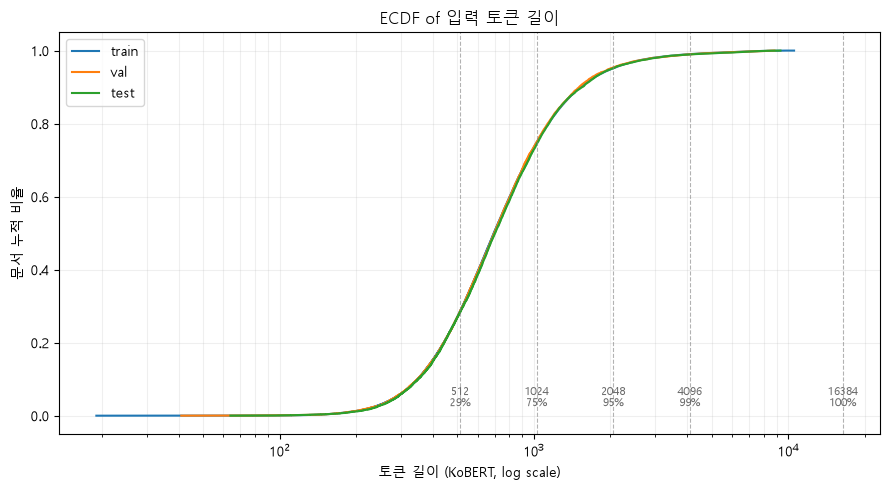

In [ ]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"]="Malgun Gothic" 

splits = {"train": train_lengths, "val": val_lengths, "test": test_lengths}
# Viz 1 — ECDF: max_len을 X로 잡을 때 무손실 문서 비율
marks = [512, 1024, 2048, 4096, 16384]

fig, ax = plt.subplots(figsize=(9, 5))
for name, L in splits.items():
    xs = np.sort(L)
    ys = np.arange(1, len(xs) + 1) / len(xs)
    ax.plot(xs, ys, label=name, lw=1.5)
for m in marks:
    ax.axvline(m, color="gray", ls="--", lw=0.8, alpha=0.6)
    ax.text(m, 0.02, f"{m}\n{(train_lengths <= m).mean():.0%}",
            fontsize=8, ha="center", va="bottom", color="dimgray")
ax.set_xscale("log")
ax.set_xlabel("토큰 길이 (KoBERT, log scale)")
ax.set_ylabel("문서 누적 비율")
ax.set_title("ECDF of 입력 토큰 길이")
ax.legend()
ax.grid(True, which="both", alpha=0.2)
plt.tight_layout()
plt.show()

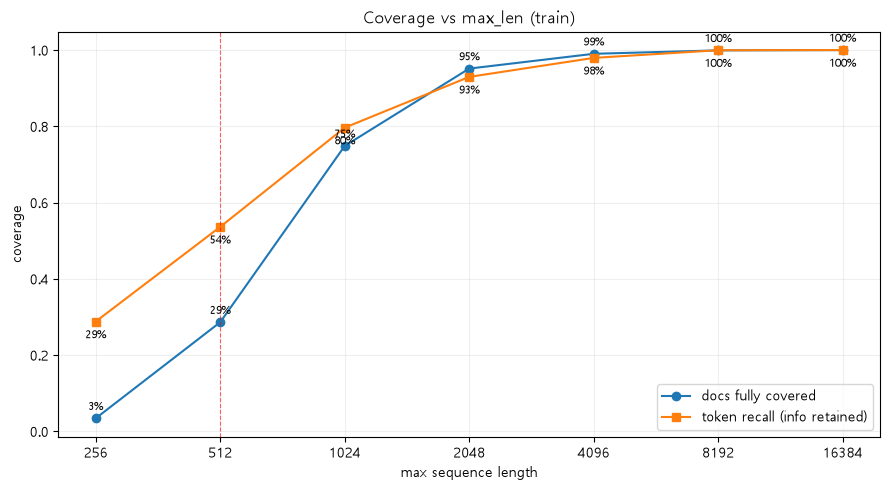

In [22]:
# Viz 2 — Coverage vs max_len (train): 문서 커버리지 + 토큰 recall(정보 보존율)
cands = [256, 512, 1024, 2048, 4096, 8192, 16384]
L = train_lengths
doc_cov = [(L <= c).mean() for c in cands]                    # max_len=c에서 무손실 문서 비율
tok_recall = [np.minimum(L, c).sum() / L.sum() for c in cands]  # 잘린 뒤 남는 전체 토큰 비율

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(cands, doc_cov, "o-", label="docs fully covered")
ax.plot(cands, tok_recall, "s-", label="token recall (info retained)")
for c, d, t in zip(cands, doc_cov, tok_recall):
    ax.annotate(f"{d:.0%}", (c, d), textcoords="offset points", xytext=(0, 6), fontsize=8, ha="center")
    ax.annotate(f"{t:.0%}", (c, t), textcoords="offset points", xytext=(0, -12), fontsize=8, ha="center")
ax.axvline(512, color="red", ls="--", lw=0.8, alpha=0.6)
ax.set_xscale("log", base=2)
ax.set_xticks(cands)
ax.set_xticklabels([str(c) for c in cands])
ax.set_xlabel("max sequence length")
ax.set_ylabel("coverage")
ax.set_title("Coverage vs max_len (train)")
ax.legend()
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

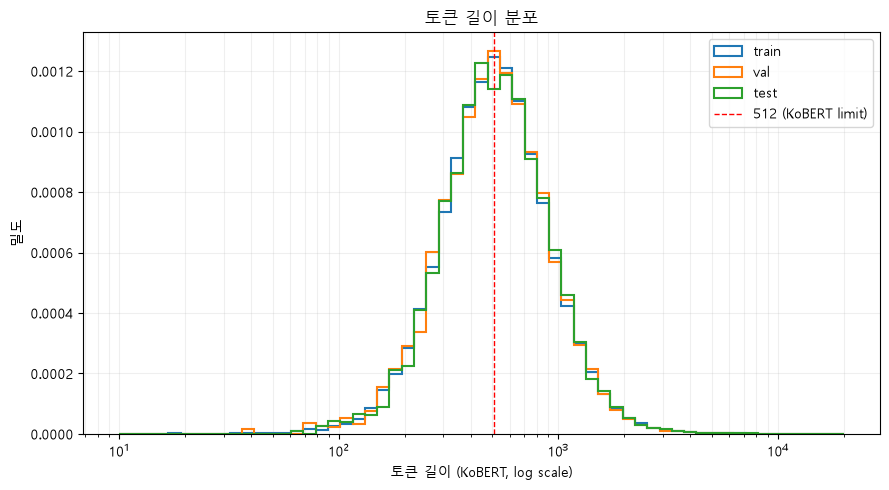

In [24]:
# Viz 3 — 길이 분포 히스토그램 (log-x): 분포 형태·롱테일 확인
bins = np.logspace(np.log10(10), np.log10(20000), 60)

fig, ax = plt.subplots(figsize=(9, 5))
for name, L in splits.items():
    ax.hist(L, bins=bins, density=True, histtype="step", lw=1.5, label=name)
ax.axvline(512, color="red", ls="--", lw=1, label="512 (KoBERT limit)")
ax.set_xscale("log")
ax.set_xlabel("토큰 길이 (KoBERT, log scale)")
ax.set_ylabel("밀도")
ax.set_title("토큰 길이 분포")
ax.legend()
ax.grid(True, which="both", alpha=0.2)
plt.tight_layout()
plt.show()

## 길이 슬라이스 bin 확정 (평가 계층화용)

장문 축 검증을 위한 **KoBERT 토큰 길이 기준 4구간**. 경계를 512의 거듭제곱 배수에 두어 truncation 심각도를 균등 스텝(보존율 100→50→25%)으로 나누고, A.X-Encoder `max_length` 스윕 지점과 정렬한다.

| bin | 토큰 길이 | truncation 정도 | macro-F1 |
|-----|---------|---------------|----------|
| B0  | ≤512      | 무손실 (control)     | ✅ |
| B1  | 512–1,024  | 경미(50–100% 보존)   | ✅ |
| B2  | 1,024–2,048 | 중간(25–50%)       | ✅ |
| B3  | >2,048     | 심함(<25%)         | ⚠️ 문서 적음 → micro 위주 |

검증 로직: `Δ(A.X − KoBERT)`가 B0에서 ≈0, B1→B3로 단조 증가하면 장문 가설 지지.

In [26]:
# 4구간 경계로 split별 실제 문서수·비율 집계
# right=True → 512는 B0, 513은 B1, 1024는 B1, 1025는 B2, 2048은 B2, 2049부터 B3
edges = [512, 1024, 2048]
bin_labels = ["B0 (<=512)", "B1 (512-1024)", "B2 (1024-2048)", "B3 (>2048)"]

print(f"{'bin':<16}{'train':>18}{'val':>18}{'test':>18}")
for b, name in enumerate(bin_labels):
    row = f"{name:<16}"
    for L in (train_lengths, val_lengths, test_lengths):
        idx = np.digitize(L, edges, right=True)
        c = int((idx == b).sum())
        row += f"{c:>10,} ({c/len(L):>5.1%})"
    print(row)

bin                          train               val              test
B0 (<=512)          57,786 (28.6%)     3,193 (28.6%)     3,197 (28.4%)
B1 (512-1024)       93,341 (46.2%)     5,174 (46.4%)     5,183 (46.0%)
B2 (1024-2048)      40,966 (20.3%)     2,279 (20.4%)     2,342 (20.8%)
B3 (>2048)           9,802 ( 4.9%)       516 ( 4.6%)       549 ( 4.9%)


In [28]:
# clean-text repo에 canonical 길이축(kobert_len) + 파생 bin(length_bin) 컬럼을 추가
from datasets import DatasetDict

bin_names = ["<=512", "512-1024", "1024-2048", ">2048"]   # edges=[512,1024,2048], right=True

def attach_length(split):
    ds = dataset[split]
    lengths = ds_tok[split]["length"]
    # map은 순서를 보존하지만, document_id 정합을 방어적으로 확인
    assert ds["document_id"] == ds_tok[split]["document_id"], f"{split} row order mismatch"
    bins = np.digitize(lengths, edges, right=True)
    ds = ds.add_column("kobert_len", lengths)
    ds = ds.add_column("length_bin", [bin_names[b] for b in bins])
    return ds

dataset_out = DatasetDict({split: attach_length(split) for split in dataset})
dataset_out

DatasetDict({
    train: Dataset({
        features: ['document_id', 'invention_title', 'abstract', 'claims', 'ipc_main', 'mno', 'label_ids', 'lno', 'kobert_len', 'length_bin'],
        num_rows: 201895
    })
    test: Dataset({
        features: ['document_id', 'invention_title', 'abstract', 'claims', 'ipc_main', 'mno', 'label_ids', 'lno', 'kobert_len', 'length_bin'],
        num_rows: 11271
    })
    val: Dataset({
        features: ['document_id', 'invention_title', 'abstract', 'claims', 'ipc_main', 'mno', 'label_ids', 'lno', 'kobert_len', 'length_bin'],
        num_rows: 11162
    })
})

In [ ]:
dataset_out.push_to_hub(
    "ingyoun/patent-clean-text",
    commit_message="add kobert_len + length_bin (recipe: title+ipc+abstract+claims, KoBERT REV 38279184)",
)